# SNR Explorer: fixed $m_1=4\times10^6\,M_\odot$

This notebook explores how the EMRI SNR changes with **time to plunge** $T_{\mathrm{pl}}$ for a fixed primary black-hole mass and spin/eccentricity settings:
- Primary mass: $m_1 = 4\times10^6\,M_\odot$
- Primary spin: $a = 0$
- Final eccentricity: $e_f = 0$

We compare four secondary-mass cases (WD, NS, and two BH masses):
- White dwarf: $m_2 = 0.6\,M_\odot$
- Neutron star: $m_2 = 1.4\,M_\odot$
- Stellar black hole (light): $m_2 = 10\,M_\odot$
- Stellar black hole (heavy): $m_2 = 30\,M_\odot$

The default setup uses deterministic orientation angles (`num_samples=1`) so repeated runs are reproducible and easy to interpret.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from snr_average import average_snr, redshift_to_luminosity_distance

plt.rcParams['figure.figsize'] = (8, 5)
plt.rcParams['axes.grid'] = True

## Physical and numerical setup

We keep cosmology/instrument assumptions fixed and vary only $T_{\mathrm{pl}}$ and $m_2$.

Notes:
- `Tobs=4.5` in `average_snr` implies $T_{\mathrm{obs}}=4.5$ years of observation.
- `z=1.86e-6` is approximately the distance to the galactic center in redshift. Redshift is a nice variable because when going to cosmological distances it affects the source-frame detector-frame relation of masses.

In [6]:
# Fixed primary and orbital settings
m1 = 4.0e6
a = 0.0
ef = 0.0

# Source-distance proxy (held fixed for comparison)
z = 1.86e-6
print("Redshift", z)
print("Luminosity Distance", redshift_to_luminosity_distance(z) * 1e6, "kpc, ", redshift_to_luminosity_distance(z) * 1e3, "Mpc", redshift_to_luminosity_distance(z), "Gpc")

# Secondary masses: WD, NS, BH, BH
m2_map = {
    'WD 0.6': 0.6,
    'NS 1.4': 1.4,
    'BH 10': 10.0,
    'BH 30': 30.0,
}

# Main plunge-time grid (years) starting from the plunging EMRIs within the LISA mission up to early EMRIs
tpl_grid = np.geomspace(4.5, 1e5, 20)
tobs = 4.5 # years

# SNR settings
psd = 'LISA'
num_freq = 100_000
num_samples = 1  # deterministic default-angle configuration in snr_average.average_snr
seed = 2601

Redshift 1.86e-06
Luminosity Distance 8.241424282934219 kpc,  0.008241424282934218 Mpc 8.241424282934218e-06 Gpc


In [7]:
def safe_average_snr(m1, m2, a, tpl, ef, z, psd='LISA', num_freq=50_000, num_samples=1, seed=2601, tobs=None):
    """Return mean SNR or np.nan if FEW integration/waveform generation fails."""
    try:
        snrs, _ = average_snr(
            m1=m1,
            m2=m2,
            a=a,
            Tpl=tpl,
            ef=ef,
            z=z,
            Tobs=tobs,
            psd=psd,
            num_freq=num_freq,
            num_samples=num_samples,
            seed=seed,
            pool=None,
        )
        val = float(np.mean(snrs))
        if not np.isfinite(val):
            return np.nan
        return val
    except Exception:
        return np.nan

In [8]:
rows = []
for label, m2 in m2_map.items():
    print(f"Computing SNR for m1={m1}, m2={m2}, a={a}, ef={ef}, z={z}")
    for tpl in tpl_grid:
        print(f"Computing SNR for Tpl={tpl} years")
        snr = safe_average_snr(
            m1=m1,
            m2=m2,
            a=a,
            tpl=float(tpl),
            ef=ef,
            z=z,
            psd=psd,
            num_freq=num_freq,
            num_samples=num_samples,
            seed=seed,
            tobs=tobs,  # if tobs=None, then Tobs=Tpl inside average_snr
        )
        rows.append({'label': label, 'm2': m2, 'Tpl_yr': float(tpl), 'SNR': snr})
    print("="*50)
scan_df = pd.DataFrame(rows)
scan_df.head()

Computing SNR for m1=4000000.0, m2=0.6, a=0.0, ef=0.0, z=1.86e-06
Computing SNR for Tpl=4.5 years
Frequency range 2 fphi: 0.0009664374041113143 - 0.0010987420641325233 Hz
Computing SNR for Tpl=7.620628709090531 years
Frequency range 2 fphi: 0.0009330343048155697 - 0.000986150869045626 Hz
Computing SNR for Tpl=12.905329315958847 years
Frequency range 2 fphi: 0.0008932104087393329 - 0.0009261239262870505 Hz
Computing SNR for Tpl=21.85482735232525 years
Frequency range 2 fphi: 0.0008467021475760498 - 0.0008678804433527629 Hz
Computing SNR for Tpl=37.010561056299274 years
Frequency range 2 fphi: 0.0007936716584649667 - 0.0008072992200079804 Hz
Computing SNR for Tpl=62.67638758337383 years
Frequency range 2 fphi: 0.000734814191652001 - 0.0007434509201376758 Hz
Computing SNR for Tpl=106.14077302220967 years
Frequency range 2 fphi: 0.0006713897718869217 - 0.000676738473265674 Hz
Computing SNR for Tpl=179.74653824402517 years
Frequency range 2 fphi: 0.0006051444569368941 - 0.000608367611946518

,label,m2,Tpl_yr,SNR
0,WD 0.6,0.6,4.500000,81850.362546
1,WD 0.6,0.6,7.620629,71194.304069
2,WD 0.6,0.6,12.905329,61620.557573
3,WD 0.6,0.6,21.854827,55262.109921
4,WD 0.6,0.6,37.010561,46977.708947


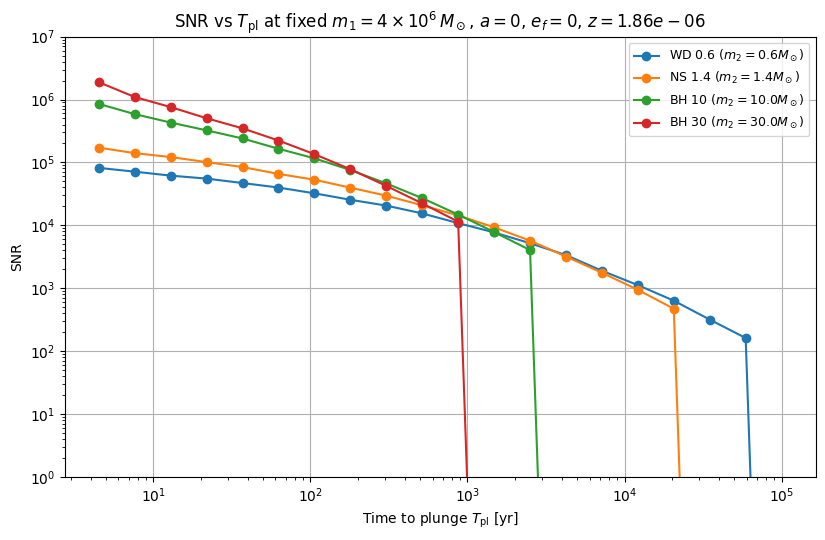

In [9]:
plt.figure(figsize=(8.5, 5.5))
for label, m2 in m2_map.items():
    sub = scan_df[scan_df['label'] == label].sort_values('Tpl_yr')
    plt.loglog(sub['Tpl_yr'], sub['SNR'], marker='o', label=f'{label} ($m_2={m2}M_\odot$)')

# plt.axhline(20, color='k', ls='--', lw=1, alpha=0.6, label='SNR=20')
plt.xlabel(r'Time to plunge $T_{\mathrm{pl}}$ [yr]')
plt.ylabel('SNR')
plt.title(r'SNR vs $T_{\mathrm{pl}}$ at fixed $m_1=4\times10^6\,M_\odot$, $a=0$, $e_f=0$, ' + f'$z={z}$')
plt.legend(fontsize=9)
plt.tight_layout()
plt.ylim(1, 1e7)
plt.show()

## Limitations (important)

1) In this pipeline, initial conditions are obtained by integrating from near separatrix and then integrating backward for a requested plunge time (`get_initial_conditions` in `snr_average.py`). For very large $T_{\mathrm{pl}}$ and/or large secondary masses, this can fail or become numerically unreliable because the backward integration goes only up to regions where FEW/flux are computed.

2) The SNR can suddenly drop if the source is out of band

3) The `num_freq` controls how many frequency points the computation is using, sometimes is good to check that this is not affecting the results